# Chapter 1 — Introduction to Image Processing

This notebook accompanies **Chapter 1 of _Introduction to Image Processing with Python_**.

The LaTeX chapter provides the formal narrative, diagrams and references. This notebook provides an executable workspace for inspecting image data and verifying the numerical ideas introduced in the chapter.

The examples are deliberately small enough to check by hand. Later notebooks will work with larger images and the reusable `pyimage` package.

## Learning objectives

By the end of this notebook, you should be able to:

- represent a small greyscale image as a NumPy array;
- inspect its shape, dimensions, data type and memory usage;
- access individual pixels and rectangular regions;
- display an array as an image;
- construct a simple histogram;
- explain why an 8-bit image data type matters during arithmetic; and
- relate a NumPy array representation to the C array representation used as historical context in the book.

## 1. Imports

Chapter 1 only needs NumPy and Matplotlib. The first cell also prints the versions in use so the notebook records the environment in which it was executed.

In [1]:
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print(f"Python:     {sys.version.split()[0]}")
print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

Python:     3.13.13
NumPy:      2.5.2
Matplotlib: 3.11.1


## 2. A first image as numerical data

The book introduces the following \(4\times4\) greyscale image. Each element is stored as an unsigned 8-bit integer (`uint8`).

In [2]:
image = np.array([
    [0,   0,  40, 40],
    [0,  60, 120, 40],
    [20, 100, 220, 80],
    [0,  40,  80,  0],
], dtype=np.uint8)

image

array([[  0,   0,  40,  40],
       [  0,  60, 120,  40],
       [ 20, 100, 220,  80],
       [  0,  40,  80,   0]], dtype=uint8)

### Historical C representation

The same values can be represented in C as a two-dimensional array:

```c
unsigned char image[4][4] = {
    { 0,   0,  40, 40 },
    { 0,  60, 120, 40 },
    {20, 100, 220, 80 },
    { 0,  40,  80,  0 }
};
```

This C example is newly written to explain the connection with the 2001 UQC146S1 module. It is not reproduced source code from the original teaching material.

The C and NumPy forms describe the same grid of values, but they expose different levels of detail about type, storage and memory management.

## 3. Inspecting the array

A NumPy array carries useful metadata in addition to the visible pixel values.

In [3]:
print(f"Number of dimensions: {image.ndim}")
print(f"Shape:                {image.shape}")
print(f"Height:               {image.shape[0]}")
print(f"Width:                {image.shape[1]}")
print(f"Number of pixels:     {image.size}")
print(f"Data type:            {image.dtype}")
print(f"Bytes per pixel:      {image.itemsize}")
print(f"Total data bytes:     {image.nbytes}")

Number of dimensions: 2
Shape:                (4, 4)
Height:               4
Width:                4
Number of pixels:     16
Data type:            uint8
Bytes per pixel:      1
Total data bytes:     16


For this greyscale image, the shape is `(4, 4)`: four rows by four columns. Since each `uint8` element occupies one byte, the raw pixel array occupies 16 bytes.

A real image file can require additional space for headers, metadata or compression structures.

## 4. Accessing pixels

NumPy uses zero-based indexing. For a two-dimensional image array, the usual form is:

```python
image[row, column]
```

This corresponds to `image[y, x]` when \(x\) is the horizontal coordinate and \(y\) is the vertical coordinate.

In [4]:
row = 2
column = 2

pixel = image[row, column]

print(f"Pixel at row {row}, column {column}: {pixel}")

Pixel at row 2, column 2: 220


In [5]:
print("Top-left pixel:    ", image[0, 0])
print("Top-right pixel:   ", image[0, -1])
print("Bottom-left pixel: ", image[-1, 0])
print("Bottom-right pixel:", image[-1, -1])

Top-left pixel:     0
Top-right pixel:    40
Bottom-left pixel:  0
Bottom-right pixel: 0


## 5. Accessing a region

Slicing lets us extract a rectangular region. Here we select the central \(2\times2\) block.

In [6]:
centre = image[1:3, 1:3]
centre

array([[ 60, 120],
       [100, 220]], dtype=uint8)

The slice `1:3` includes indices 1 and 2 but excludes index 3. Slicing becomes especially important later when working with image neighbourhoods and convolution.

## 6. Displaying the image

The array is the image data. Matplotlib provides a visual interpretation of those values.

The display range is fixed at 0–255 so the same intensity value is mapped consistently.

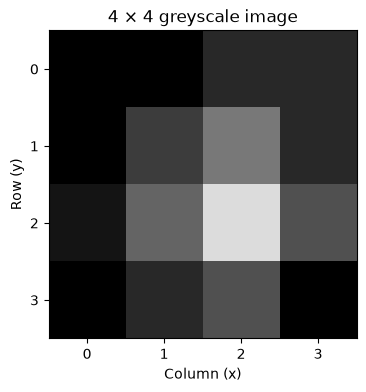

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.imshow(image, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
ax.set_title("4 × 4 greyscale image")
ax.set_xlabel("Column (x)")
ax.set_ylabel("Row (y)")
ax.set_xticks(range(image.shape[1]))
ax.set_yticks(range(image.shape[0]))

plt.show()

## 7. Showing the pixel values

For a tiny teaching image, placing each numerical value on top of the rendered pixel makes the connection between data and appearance explicit.

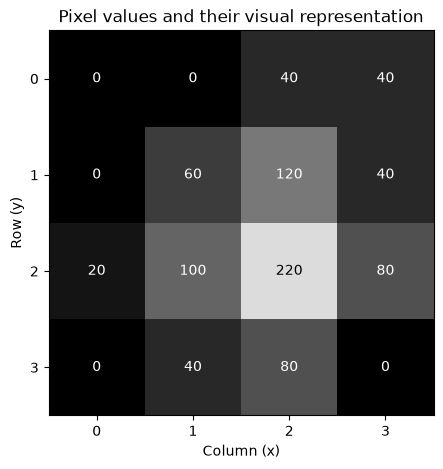

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(image, cmap="gray", vmin=0, vmax=255, interpolation="nearest")

for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        value = int(image[y, x])
        text_colour = "white" if value < 128 else "black"
        ax.text(x, y, str(value), ha="center", va="center", color=text_colour)

ax.set_title("Pixel values and their visual representation")
ax.set_xlabel("Column (x)")
ax.set_ylabel("Row (y)")
ax.set_xticks(range(image.shape[1]))
ax.set_yticks(range(image.shape[0]))

plt.show()

## 8. A first histogram

A histogram counts how often each intensity occurs. Before introducing a dedicated histogram chapter, we can inspect the unique values and their frequencies directly.

In [9]:
values, counts = np.unique(image, return_counts=True)

for value, count in zip(values, counts):
    print(f"{int(value):3d}: {int(count)}")

  0: 5
 20: 1
 40: 4
 60: 1
 80: 2
100: 1
120: 1
220: 1


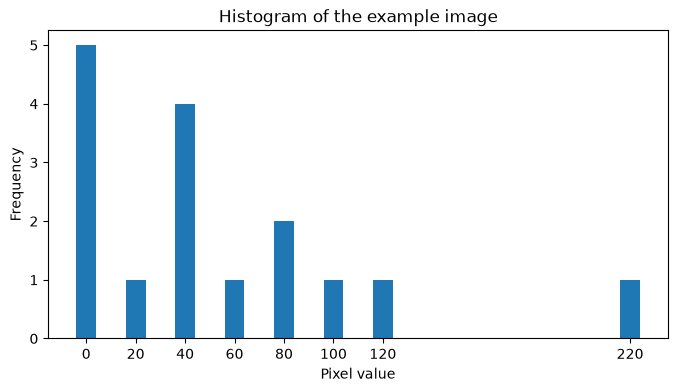

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(values, counts, width=8)
ax.set_title("Histogram of the example image")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Frequency")
ax.set_xticks(values)
ax.set_ylim(bottom=0)

plt.show()

The result is easy to verify manually:

- `0` occurs five times;
- `40` occurs four times;
- `80` occurs twice;
- each remaining displayed value occurs once.

Later chapters will develop image statistics and histograms in much greater detail.

## 9. Why the data type matters

The image uses `np.uint8`, so each stored value must lie between 0 and 255.

Suppose a pixel with value 250 is increased by 20:

\[
250 + 20 = 270
\]

The result 270 cannot be stored directly as an unsigned 8-bit image value. The algorithm therefore needs an explicit policy.

A common approach is:

1. calculate in a wider type;
2. clip the result to the valid output range; and
3. convert back to the required image type.

In [11]:
pixel = np.uint8(250)
amount = 20

intermediate = int(pixel) + amount
clipped = np.clip(intermediate, 0, 255)
result = np.uint8(clipped)

print(f"Stored pixel:        {pixel}")
print(f"Intermediate value:  {intermediate}")
print(f"Clipped value:       {clipped}")
print(f"Final uint8 result:  {result}")

Stored pixel:        250
Intermediate value:  270
Clipped value:       255
Final uint8 result:  255


The original C material raised the same underlying concern when moving between `unsigned char` image storage and wider integer calculations. The syntax changes in Python/NumPy, but the numerical issue remains.

## 10. A preview of a point operation

Brightness adjustment is covered properly later in the book. Here it is used only as a preview of the idea that image processing transforms numerical data.

The calculation is deliberately performed in a wider integer type before clipping.

In [12]:
amount = 40

brighter = image.astype(np.int16) + amount
brighter = np.clip(brighter, 0, 255).astype(np.uint8)

brighter

array([[ 40,  40,  80,  80],
       [ 40, 100, 160,  80],
       [ 60, 140, 255, 120],
       [ 40,  80, 120,  40]], dtype=uint8)

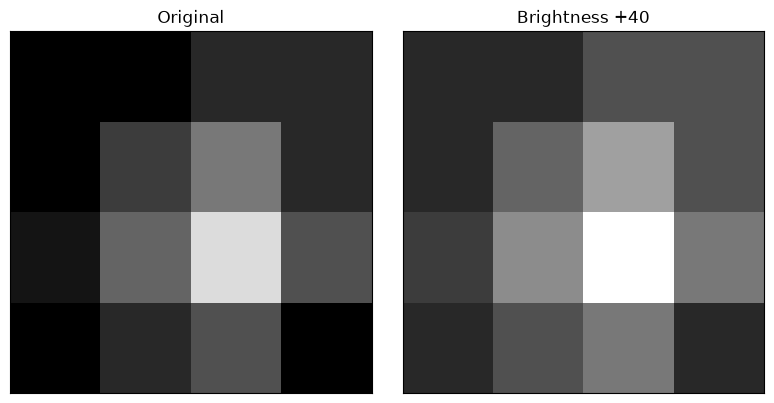

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title("Original")

axes[1].imshow(brighter, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[1].set_title("Brightness +40")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

This is intentionally not the final library implementation. The later point-processing chapter will define a reusable function, test its boundaries and compare it with higher-level approaches.

## 11. Notebook, package and tests

The notebooks are exploratory companions, not the permanent home of reusable algorithms.

The workflow used throughout the book will be:

1. understand the concept and mathematics;
2. examine the C approach where useful;
3. experiment in the chapter notebook;
4. implement the Python version;
5. validate it numerically and visually;
6. move the final implementation into `project/src/pyimage/`;
7. add independent tests under `project/tests/`; and
8. compare the result with established libraries where appropriate.

This avoids making the finished project dependent on hidden notebook state.

## 12. Worked experiments

These exercises are included with complete solution cells because the notebooks are being developed as self-study material.

### Experiment A — change one pixel

Create a copy of the image, change the pixel at row 1, column 1 to 255, and display it.

### Experiment B — inspect another region

Extract the top-right \(2\times2\) region.

### Experiment C — calculate the mean manually

Add all 16 pixel values and divide by 16, then compare the result with `image.mean()`.

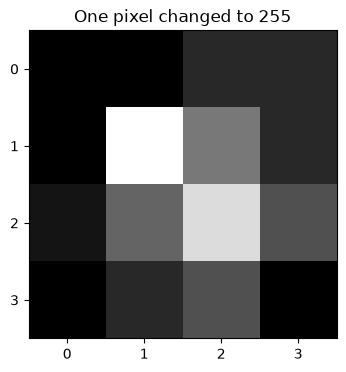

In [14]:
# Experiment A
changed = image.copy()
changed[1, 1] = 255

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(changed, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
ax.set_title("One pixel changed to 255")
ax.set_xticks(range(changed.shape[1]))
ax.set_yticks(range(changed.shape[0]))

plt.show()

In [15]:
# Experiment B
top_right = image[0:2, 2:4]
top_right

array([[ 40,  40],
       [120,  40]], dtype=uint8)

In [16]:
# Experiment C
manual_mean = sum(int(value) for value in image.flat) / image.size
numpy_mean = image.mean()

print(f"Manual mean: {manual_mean}")
print(f"NumPy mean:  {numpy_mean}")

Manual mean: 52.5
NumPy mean:  52.5


## 13. Summary

In this notebook we have:

- represented a greyscale image as a `uint8` NumPy array;
- inspected its dimensions, shape, element count and memory usage;
- accessed individual pixels and rectangular regions;
- displayed the numerical array as an image;
- counted intensities and plotted a simple histogram;
- demonstrated why image arithmetic must consider the output data type;
- previewed a point-processing operation; and
- established the notebook → package → tests workflow used by the rest of the project.

The next notebook will accompany the chapter on Anaconda, Visual Studio Code and Jupyter.

## References

1. I. Johnson, *UQC146S1: Introductory Image Processing in C*, introductory lecture material, University of the West of England, 2001.
2. I. Johnson, *UQC146S1 — An Introduction to Image Processing in C: Portfolio of Work*, University of the West of England, 2001–2002.
3. NumPy Developers, *NumPy documentation*. The complete publication entry is maintained in the book's master bibliography.

The historical material is used for context and provenance. The explanations, Python code and reconstructed C example in this notebook are newly written for this project.